[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/IvanNece/LABS_ML_Vision_Multimedia/blob/main/Lab01_IntroductionToPyTorch/mnist_classification_pytorch.ipynb)

# MNIST Classification

**Import packages**

In [1]:
import argparse
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms

## Define a fully connected Neural Network
We define a very simple fully connected neural network. It is a subclass of torch.nn.Module. <br>
When extending torch.nn.Module we need to define two methods:

`__init__` method:
it is the constructor of the class and is called only once, when instantiating the neural network. It initializes the network's architecture by initializing all network layers and other components. It is where you define the structure of the network, such as layers, activation functions, and any other components required for computation.

`forward` method
is called when you pass input data through the network. The forward method specifies the sequence of operations that are applied to the input data. It describes how the input data flow through the various layers to produce the final output.

### 🧩 Building a Simple Feed-Forward Network for Image Classification

Here we define a fully connected neural network in PyTorch that classifies grayscale images of size 28 by 28 (like MNIST). The goal is to turn each image into a set of logits (unnormalized scores), one per class, which we will later pass to a loss function such as CrossEntropyLoss.

### 🏗️ Class structure and layers

`class NeuralNetwork(nn.Module)`
A custom model that inherits from nn.Module. This gives us a standard structure: define layers in __init__, and define the data flow in forward.

`num_classes`
Number of output categories (for MNIST this is 10). The final layer will produce one score per class.

`self.flatten = nn.Flatten()`
Converts each input image from shape (batch_size, 1, 28, 28) to a single vector (batch_size, 28*28). This prepares the data for linear layers.

*Hidden layers*

`lin1 = nn.Linear(28*28, 512)` then `act1 = nn.ReLU()`
First dense layer: projects the 784-dimensional image vector to 512 features, then applies ReLU to add nonlinearity.

`lin2 = nn.Linear(512, 512)` then `act2 = nn.ReLU()`
Second dense block: keeps feature size at 512 and applies another ReLU. Stacking helps learn more complex patterns.

*Output layer*

`output_layer = nn.Linear(512, num_classes)`
Maps the 512 features to num_classes logits. These are raw scores; we do not apply softmax here because nn.CrossEntropyLoss expects logits and applies softmax internally.

### 🔄 Forward pass: step by step

Flatten
`x = self.flatten(x)`
Shape goes from (batch, 1, 28, 28) to (batch, 784).

Block 1
`x1 = self.lin1(x) → x1 = self.act1(x1)`
Linear transform then ReLU activation.

Block 2
`x2 = self.lin2(x1) → x2 = self.act2(x2)`
Another linear + ReLU to deepen the model.

Output
`logits = self.output_layer(x2)`
Final scores with shape (batch, num_classes). Higher score means the model leans toward that class. During training, the loss function will compare these logits to the true labels.

### 📌 Why this design?

Flatten + Linear layers are simple and fast for small images; good starting point before moving to CNNs.

ReLU avoids vanishing gradients and speeds up training.

Logits output integrates smoothly with CrossEntropyLoss, which combines softmax + negative log likelihood in a numerically stable way.

In [4]:
# Define a custom neural network class by extending nn.Module
class NeuralNetwork(nn.Module):
    def __init__(self, num_classes):
        # Call the parent class constructor (nn.Module) to initialize properly
        super().__init__()

        # --- INPUT PREPROCESSING ---
        # Flatten layer: converts each 28x28 image into a single vector of size 784 (28*28)
        # This prepares the image to be passed into fully connected (linear) layers.
        self.flatten = nn.Flatten()

        # --- FIRST HIDDEN LAYER ---
        # Linear layer: takes the 784 input features (pixels) and produces 512 outputs
        # Each output is a weighted sum of the inputs plus a bias term.
        self.lin1 = nn.Linear(28*28, 512)
        # Activation function (ReLU): replaces all negative values with 0
        # This introduces non-linearity, allowing the network to learn complex patterns.
        self.act1 = nn.ReLU()

        # --- SECOND HIDDEN LAYER ---
        # Another linear layer: transforms 512 input features into 512 outputs
        # It further combines and abstracts the features learned from the first layer.
        self.lin2 = nn.Linear(512, 512)
        # Another ReLU activation to add non-linearity after the second transformation
        self.act2 = nn.ReLU()

        # --- OUTPUT LAYER ---
        # Final linear layer: maps the 512 learned features into 'num_classes' outputs
        # (For MNIST, num_classes = 10 for digits 0–9)
        # The outputs are called "logits" — they are raw, unnormalized scores.
        self.output_layer = nn.Linear(512, num_classes)

    # Define the forward pass: how data flows through the network
    def forward(self, x):
        # 1️⃣ Flatten input: from (batch_size, 1, 28, 28) → (batch_size, 784)
        x = self.flatten(x)

        # 2️⃣ First hidden layer: apply linear transformation and then ReLU activation
        x1 = self.lin1(x)   # Linear: 784 → 512
        x1 = self.act1(x1)  # Apply non-linearity

        # 3️⃣ Second hidden layer: another linear + ReLU combination
        x2 = self.lin2(x1)  # Linear: 512 → 512
        x2 = self.act2(x2)  # Apply non-linearity

        # 4️⃣ Output layer: final linear transformation, no activation here
        # (because we'll apply softmax inside the loss function)
        logits = self.output_layer(x2)  # 512 → num_classes (e.g., 10)

        # Return logits (raw scores) for each class
        return logits


### 🧠 What happens to one image — step by step

The image enters the network
You start with a small grayscale image of a handwritten number (for example, a 28×28 picture of the digit “5”).
At this point, the image is just 784 pixel values (28×28 = 784), each between 0 and 1.

-Flattening (turn into a long list)
The network first flattens the image — it takes all the pixels and puts them into one long line, like writing all numbers next to each other.
Now the network sees it as a vector of length 784, not as a 2D picture anymore.

-First linear layer (basic pattern learning)
The first layer takes all 784 numbers and mixes them together using weights and biases.
Each of the 512 outputs is like a “feature” — it might detect small patterns such as edges, shapes, or parts of digits.

-First ReLU activation (keep only strong signals)
After the first mix, ReLU keeps only the positive signals and sets negative ones to zero.
This helps the network focus on what’s important and makes it nonlinear — meaning it can now learn more complex shapes, not just straight lines.

-Second linear + ReLU (combine deeper features)
The next layer again mixes those 512 features to produce another 512 features.
Now the network can detect combinations of patterns — for example, curves that look like “8” or corners that look like “7”.
The second ReLU again keeps only the strong activations.

-Output layer (final decision)
The last layer takes those 512 deep features and produces 10 output values — one for each possible digit (0–9).
These values are called logits, meaning they are not yet probabilities.

After the model (loss or prediction)
During training, these logits go into a softmax (inside CrossEntropyLoss) that turns them into probabilities.
The highest probability tells us what digit the model believes the image represents.

### 🔁 So, in short


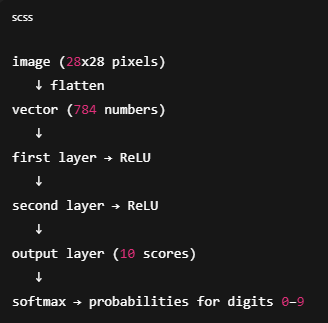

## Dataset

### 🧠 Preparing and Loading the MNIST Dataset

In this step, we prepare the MNIST dataset, which contains 70,000 grayscale images of handwritten digits (0–9). Each image is 28×28 pixels, and each digit belongs to one of 10 possible classes.
The goal of this preprocessing step is to convert raw image data into normalized tensors that can be directly fed into our neural network.

### 🧩 Data preprocessing

We define a transform pipeline using torchvision.transforms.Compose().
This allows us to apply a series of transformations to each image automatically when it is loaded.

`transforms.ToTensor()`
Converts a PIL image (or NumPy array) into a PyTorch tensor, and scales pixel values from [0, 255] to [0, 1].
This is essential because neural networks expect floating-point tensors, not raw image arrays.

`transforms.Normalize(mean, std)`
Standardizes the pixel values by subtracting the dataset mean and dividing by its standard deviation.
The values (0.1307, 0.3081) are the empirical mean and std for the MNIST dataset.
After normalization, most pixel values will lie around 0, which helps the model converge faster during training.

### 📦 Creating the training and test datasets

We use torchvision.datasets.MNIST, which automatically downloads and prepares the dataset:

`train=True` loads the 60,000 training images.

`train=False `loads the 10,000 test images used for evaluation.

The transform argument ensures that each image is automatically converted and normalized when accessed.

`download=True` downloads the dataset if it is not already present in the directory.

### 📊 Verifying the data

When we print the dataset lengths. We confirm that we have successfully loaded all MNIST samples.
At this stage, the images are preprocessed, standardized, and ready to be passed to a DataLoader for batching during training.

In [3]:
from torchvision import datasets, transforms

# preprocessing to apply on each data sample:
# 1) convert to tensor
# 2) normalize images
transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=(0.1307,), std=(0.3081,))  # Normalize a tensor image with mean and standard deviation.
        ])

# train dataset
train_dataset = datasets.MNIST('../data', train=True, download=True, transform=transform)
print(f"MNIST train dataset - num samples: {len(train_dataset)}")

# test dataset
test_dataset = datasets.MNIST('../data', train=False, transform=transform)
print(f"MNIST test dataset - num samples: {len(test_dataset)}")

100%|██████████| 9.91M/9.91M [00:00<00:00, 19.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 503kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.73MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.30MB/s]


MNIST train dataset - num samples: 60000
MNIST test dataset - num samples: 10000


### Plot one sample from dataset

When we access an element from the dataset like this:

* The dataset returns a tuple (image, label).

* image is a PyTorch tensor containing the pixel values of the 100th image.

* label is an integer (0–9) representing which digit the image shows.

So, one `sample = (input image, target digit)`.




In [13]:
# dataset returns one sample at a time
# In our case one sample corresponds to a Tuple: (Image, Target Label)
# Image is a tensor with shape [1, 28, 28]
# Label is an integer representing the class of the image

print(type(train_dataset[100]))
print(len(train_dataset[100]))

image, label = train_dataset[100]
print("image: ", image.shape, type(image))
print("label: ", label, type(label))

<class 'tuple'>
2
image:  torch.Size([1, 28, 28]) <class 'torch.Tensor'>
label:  5 <class 'int'>


This tells us that the image has:

* 1 channel → because it is a grayscale image (unlike RGB images which have 3 channels).

* 28 × 28 pixels → the height and width of the image.

So, the tensor shape follows the PyTorch convention `[Channels, Height, Width]`.



In [9]:
image.shape

torch.Size([1, 28, 28])

By selecting the first (and only) channel with image[0], we remove the channel dimension and obtain a simple 2D array.
This is often useful when you want to plot or display the image using libraries like Matplotlib, which expect 2D data for grayscale images.

In [10]:
image[0].shape

torch.Size([28, 28])

The `.view()` method reshapes the tensor into a new form without changing its data.
Here, it flattens the channel dimension automatically, giving the same result as image[0].
Now the tensor is ready to be visualized with `plt.imshow(image.numpy())`.

In [11]:
image = image.view(28,28)
image.shape

torch.Size([28, 28])

### 🖼️ Interpreting the Displayed MNIST Image

The image you see is a visual representation of one MNIST sample — in this case, the handwritten digit 5.
Let’s break down what you are actually looking at.

### 🧩 What the plot shows

Each square (pixel) in the grid represents one of the 28 × 28 pixels of the original MNIST image.

The colors represent the intensity (brightness) of each pixel.

Bright yellow = high pixel value (close to 1 after normalization) → parts of the digit where the ink is strong.

Dark purple = low pixel value (close to 0 or negative after normalization) → empty background.

The digit is centered in the image and occupies the middle area.
This normalization of position and size is part of how MNIST was preprocessed originally.

### 🔢 Relation with the label

The label = 5 means this image belongs to the class “5”.
So visually, you are seeing a handwritten number 5, written in a slightly curved style — thick in some places, thinner in others.

Even though the image is pixelated, the pattern of bright pixels forms the clear shape of a “5”, and that’s what the neural network will learn to recognize.

### ⚙️ How the network sees it

While you see the digit as a shape, the network sees it as a matrix of numbers:

Each pixel is a value between approximately -1 and +1 (after normalization).

These numbers are then flattened into a vector of 784 values before entering the neural network.

The network does not see the color — it only uses these numerical patterns to learn what makes a “5” different from a “3” or a “2”.

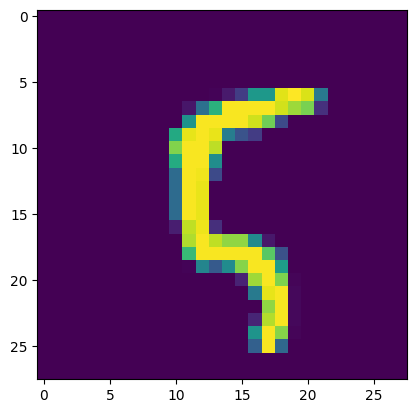

In [12]:
# plot one sample normalized

import matplotlib.pyplot as plt
plt.imshow(image.numpy())  # numpy array 28x28

## Dataloader
Dataloader reads from the dataset and returns batches of data.

Goal: turn the dataset into mini-groups of examples that the
model can read efficiently during training and testing.

Key definitions:

* Sample: one data point = one image + its label.
In MNIST: a 28×28 tensor and an integer 0–9.

* Batch: a small group of samples processed together in one step.
Here batch_size = 128, so each step the model sees 128 images and computes one loss and one gradient update.

* Iteration / Step: one forward + backward pass on one batch.

* Epoch: one full pass over the entire dataset.
Steps per epoch ≈ total_samples / batch_size.


What the code sets up:
* `dataset`: the source of samples (train_dataset or test_dataset).

* `batch_size`: how many samples per batch (memory vs. speed trade-off; larger is faster but needs more RAM/GPU).

* `shuffle=True (train)`: reshuffles sample order every epoch to reduce overfitting and make training more stable.

* `shuffle=False (test)`: keeps a fixed order for deterministic evaluation.

* `drop_last (optional)`: if True, drops the last smaller batch; usually False so you use all data.

In [14]:
batch_size = 128  # we define here the batch size: number of samples processed before the model is updated
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True) #, drop_last=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False) # , drop_last=False)
print(f"batch size: {batch_size}")

batch size: 128


## Training

## 🧠 Training and Evaluation: General Explanation

This part of the notebook defines two essential functions that control how the model learns and how its performance is evaluated.

The `train()` function is responsible for the learning process, while the `test()` function checks how well the model performs on unseen data.

During training, the function goes through the dataset batch by batch. Each batch contains a small group of images and their correct labels. For each batch, the model makes predictions, compares them with the true labels using a loss function (cross-entropy), and computes the error. Then, through backpropagation, PyTorch automatically calculates how much each weight contributed to that error.
Finally, the optimizer adjusts the weights slightly in the direction that reduces the loss. This process repeats for every batch and every epoch until the model gradually learns the patterns that map images to the correct digits.


In [18]:
# function for training
def train(model, device, train_loader, optimizer, epoch):
    model.train()  # model to train mode

    # ITERATE DATALOADER: train_loader
    for batch_idx, (data, target) in enumerate(train_loader):
        #  SINGLE OPTIMIZATION STEP IS PERFORMED ON A BATCH!
        data, target = data.to(device), target.to(device)

        optimizer.zero_grad()

        output = model(data)

        loss = F.cross_entropy(output, target)

        loss.backward()

        optimizer.step()

        if batch_idx % 50 == 0:
            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
                epoch, batch_idx * len(data), len(train_loader.dataset),
                100. * batch_idx / len(train_loader), loss.item()))

In contrast, the `test()`function is used only to measure how well the model generalizes. Here, the model is put in evaluation mode, which disables training-specific behaviors like dropout. It processes the test dataset without changing its weights. The function accumulates the total loss and counts how many predictions are correct, computing the average loss and the accuracy over the entire test set.



---



Together, these two functions form the typical training loop in PyTorch:

* Train on the training data (model learns).

* Evaluate on the test data (model is validated).

* Repeat this for several epochs (full passes over the training set) until performance stops improving.

In short:
* ➡️ train() makes the model learn from mistakes.
* ➡️ test() checks if that learning actually works on new, unseen examples.

In [19]:
# test
# function for evaluation
def test(model, device, test_loader):
    model.eval()  # model to eval
    test_loss = 0
    correct = 0

    # ITERATE DATALOADER: test_loader
    for data, target in test_loader:
        batch_size = data.shape[0]
        data, target = data.to(device), target.to(device)
        output = model(data)
        test_loss += F.cross_entropy(output, target, reduction='sum').item()  # sum up batch loss

        pred = output.argmax(dim=1, keepdim=True)  # get the index of the max log-probability

        # sanity check
        pred = pred.view(batch_size)  # [bs,]
        target = target.view(batch_size)  # [bs,]

        # compute prediction ok
        batch_pred_ok = pred.eq(target).sum().item()
        correct += batch_pred_ok

    test_loss /= len(test_loader.dataset)
    num_samples = len(test_loader.dataset)
    test_accuracy = correct / num_samples
    print('\nTest set: Average loss: {:.4f}, Accuracy: {}/{} ({:.0f}%)\n'.format(
        test_loss, correct, len(test_loader.dataset),
        100. * correct / len(test_loader.dataset)))

## ⚙️ Training Setup — General Explanation

In this part of the notebook, we prepare everything needed before starting the actual training process.
The code defines the environment, the hyperparameters, the model, and the optimizer — essentially setting the stage for learning.

***Computation device:***

The code first selects the GPU (cuda) if available, otherwise the CPU.
Using the GPU allows PyTorch to execute operations much faster thanks to parallel computation.

***Training hyperparameters:***

* Learning rate (lr = 0.01) → controls how big each update step will be when adjusting the model’s weights.

* Number of epochs (num_epochs = 5) → defines how many times the model will go through the entire training dataset.

* Batch size (128) → the number of images processed before each weight update. For MNIST, this means around 468 optimization steps per epoch.

***Model creation:***

The code builds an instance of the NeuralNetwork class with 10 output classes (digits 0–9).
Then it moves the model to the selected device (model.to(device)), ensuring that all computations happen in the same place as the data.

***Optimizer setup:***

It uses Stochastic Gradient Descent (SGD), one of the most common optimization algorithms.

* The optimizer updates the model’s parameters based on the gradients computed during backpropagation.

* It uses the learning rate to determine how much each parameter should change.

* The momentum (0.9) adds stability by keeping some of the direction from previous updates, helping the model converge faster and avoid oscillations.


In summary:
This block doesn’t perform training yet — it prepares the entire training environment:

In [20]:
device = torch.device('cuda')  # use gpu, is equivalent to .cuda()

# training hyperparameters
lr = 0.01
num_epochs = 5
print(f"lr: {lr}")
print(f"batch size: {batch_size}")
print(f"Num. optimization steps per-epoch: {int(len(train_dataset)/batch_size)}")

#########
# MODEL #
#########
model = NeuralNetwork(num_classes=10)
model = model.to(device)

#############
# OPTIMIZER #
#############
parameters_to_optimize = model.parameters()
optimizer = optim.SGD(parameters_to_optimize, lr=lr, momentum=0.9)

lr: 0.01
batch size: 128
Num. optimization steps per-epoch: 468


## 🚀 Training Loop — General Explanation

This section runs the complete training process of the neural network through several epochs, alternating between training and evaluation phases.

The code executes a loop that repeats five times — one for each epoch — where the model first learns from the training data and then is tested on unseen data to measure its progress. The %%time command simply measures how long the entire operation takes from start to finish.

### 🧩 What happens during each epoch

During the training phase, the model processes the entire training dataset in small groups of images (batches).
For each batch, it predicts which digit it sees, compares its prediction with the true label, calculates the error, and adjusts its internal weights to reduce that error. As the training continues, the loss values printed in the output get smaller, showing that the model is improving.

Once all training batches are completed, the evaluation phase begins. Here the model is switched to evaluation mode and tested on the separate test dataset. This step does not change the model’s weights; it only checks how well the network performs on new data. The average loss and accuracy are calculated and displayed at the end of each epoch.

### 🚀 In other words
An epoch means the model has seen all the training images once — in MNIST, that’s 60,000 images.
However, the network doesn’t process them one by one but in small groups called batches.
* The DataLoader splits the dataset into batches (for example, 128 images each).
* For each batch: The images pass through the network (forward pass) + The model’s predictions are compared with the true labels (loss) + Gradients are computed (backward pass) + The optimizer updates the weights slightly (step).
* After all batches are processed, the epoch ends — the model has “seen” every image once.

Then the next epoch starts: the data is shuffled, and the model repeats the process, improving its weights a bit more each time.
After several epochs, the model becomes more accurate and generalizes better.

In [21]:
%%time
for epoch in range(1, num_epochs + 1):
  train(model, device, train_loader, optimizer, epoch)
  test(model, device, test_loader)

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.302931
Train Epoch: 1 [6400/60000 (11%)]	Loss: 0.489439
Train Epoch: 1 [12800/60000 (21%)]	Loss: 0.355422
Train Epoch: 1 [19200/60000 (32%)]	Loss: 0.398046
Train Epoch: 1 [25600/60000 (43%)]	Loss: 0.373640
Train Epoch: 1 [32000/60000 (53%)]	Loss: 0.163102
Train Epoch: 1 [38400/60000 (64%)]	Loss: 0.125840
Train Epoch: 1 [44800/60000 (75%)]	Loss: 0.124647
Train Epoch: 1 [51200/60000 (85%)]	Loss: 0.158402
Train Epoch: 1 [57600/60000 (96%)]	Loss: 0.115835

Test set: Average loss: 0.1676, Accuracy: 9520/10000 (95%)

Train Epoch: 2 [0/60000 (0%)]	Loss: 0.118228
Train Epoch: 2 [6400/60000 (11%)]	Loss: 0.197323
Train Epoch: 2 [12800/60000 (21%)]	Loss: 0.279466
Train Epoch: 2 [19200/60000 (32%)]	Loss: 0.181086
Train Epoch: 2 [25600/60000 (43%)]	Loss: 0.158727
Train Epoch: 2 [32000/60000 (53%)]	Loss: 0.223598
Train Epoch: 2 [38400/60000 (64%)]	Loss: 0.082095
Train Epoch: 2 [44800/60000 (75%)]	Loss: 0.081891
Train Epoch: 2 [51200/60000 (85%)]	Loss: 0.111974
T

## 📊 How to interpret the output

The printed results show the progress of learning. Each line beginning with “Train Epoch” indicates how far through the current epoch the model has gone and the current loss value. As epochs progress, the loss gradually decreases, meaning the network is learning effectively.

After each epoch, the summary line “Test set: Average loss … Accuracy …” reports how well the model performs on unseen examples. You can see accuracy rising from about 95% in the first epoch to around 98% by the fifth one — a clear sign of successful learning.

### ✅ Summary

The loop performs five full passes over the training set.

Each epoch includes both a training and a testing phase.

Training reduces the loss and improves the model’s predictions.

Testing confirms the improvement and measures how well the model generalizes.

The total execution time shows how long the whole learning process took.

In short, this block carries out the core learning cycle of deep learning: the model learns from data, is evaluated, and progressively becomes more accurate with each epoch.